**Importation des bibliothèques**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

**Chargement du Dataset**

In [3]:
df = pd.read_csv("AmesHousing.csv")

print(df.shape)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


**Analyse des valeurs manquantes**

In [4]:
VM = pd.DataFrame({
'Colonne': df.columns.values,
'nbr de VM': df.isna().sum().values,
'% de VM': 100 * df.isna().sum().values / len(df)
})

VM = VM[VM['nbr de VM'] > 0]

print(VM.sort_values(by='nbr de VM', ascending=False).reset_index(drop=True))

           Colonne  nbr de VM    % de VM
0          Pool QC       2917  99.556314
1     Misc Feature       2824  96.382253
2            Alley       2732  93.242321
3            Fence       2358  80.477816
4     Mas Vnr Type       1775  60.580205
5     Fireplace Qu       1422  48.532423
6     Lot Frontage        490  16.723549
7      Garage Qual        159   5.426621
8      Garage Cond        159   5.426621
9    Garage Yr Blt        159   5.426621
10   Garage Finish        159   5.426621
11     Garage Type        157   5.358362
12   Bsmt Exposure         83   2.832765
13  BsmtFin Type 2         81   2.764505
14       Bsmt Cond         80   2.730375
15       Bsmt Qual         80   2.730375
16  BsmtFin Type 1         80   2.730375
17    Mas Vnr Area         23   0.784983
18  Bsmt Full Bath          2   0.068259
19  Bsmt Half Bath          2   0.068259
20    BsmtFin SF 1          1   0.034130
21    BsmtFin SF 2          1   0.034130
22      Electrical          1   0.034130
23   Total Bsmt 

**Suppression des colonnes avec beaucoup de valeurs manquantes**

In [5]:
df = df.dropna(axis=1, thresh=len(df)*0.7)

**Remplacement des valeurs manquantes**

Variables numériques → moyenne

In [6]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

Variables catégorielles → mode

In [7]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

**Encodage des variables catégorielles**

In [8]:
df = pd.get_dummies(df)

**Séparation des données**

Variable cible = SalePrice

In [9]:
train = df.sample(frac=0.8, random_state=9)
test = df.drop(train.index)

train_target = train.pop("SalePrice")
test_target = test.pop("SalePrice")

**Standardisation**

In [10]:
for col in train.columns:
    mean = train[col].mean()
    std = train[col].std()

    if std == 0:
        std = 1e-20

    train[col] = (train[col] - mean) / std
    test[col] = (test[col] - mean) / std

**Création du modèle Deep Learning**

Modification pour de meilleurs résultats :

Plus de neurones

Dropout

Activation ReLU

Optimizer Adam

In [12]:
model = keras.Sequential([
layers.Dense(128, activation='relu', input_shape=[train.shape[1]]),
layers.Dropout(0.3),
layers.Dense(128, activation='relu'),
layers.Dense(64, activation='relu'),
layers.Dense(32, activation='relu'),
layers.Dense(1)
])

**Compilation du modèle (Adam)**

In [13]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
loss=tf.keras.losses.MeanSquaredError(),
optimizer=optimizer,
metrics=['mae']
)

**Entrainement du modèle**

In [14]:
training = model.fit(
train,
train_target,
epochs=100,
validation_split=0.2,
batch_size=32
)

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 38865207296.0000 - mae: 180450.8438 - val_loss: 40243728384.0000 - val_mae: 182178.9375
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35950333952.0000 - mae: 174587.3594 - val_loss: 19190810624.0000 - val_mae: 127755.7344
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11229832192.0000 - mae: 91301.4062 - val_loss: 4042832640.0000 - val_mae: 47496.8086
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3156703488.0000 - mae: 41580.9062 - val_loss: 2765000960.0000 - val_mae: 35711.7500
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2133774976.0000 - mae: 33712.3750 - val_loss: 2480867584.0000 - val_mae: 33066.0000
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1841578880.0000 - mae: 29967.7441 - val_loss: 2306320384.0000 - val_mae: 31253.9434
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1479478912.0000 - mae: 28082.5312 - val_loss: 2150168832.0000 - val_mae: 2

**Visualisation des performances**

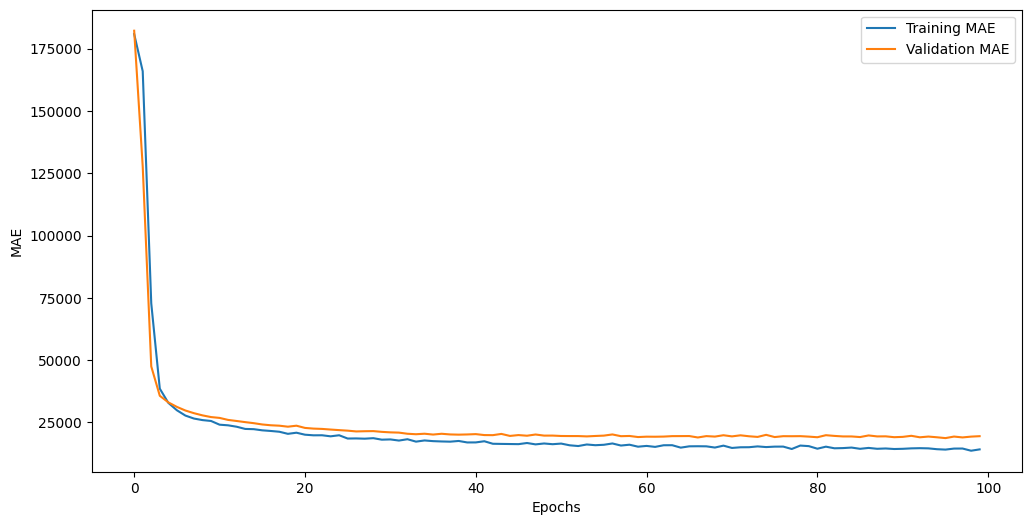

In [15]:
history = pd.DataFrame(training.history)

plt.figure(figsize=(12,6))

plt.plot(history["mae"], label="Training MAE")
plt.plot(history["val_mae"], label="Validation MAE")

plt.legend()
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.show()

**Test du modèle**

In [16]:
test1 = test.iloc[[10]]

prediction = model.predict(test1).squeeze()

real_value = test_target.iloc[10]

print("Prediction :", prediction)
print("Valeur réelle :", real_value)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Prediction : 290385.2
Valeur réelle : 259000
